In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/content/Mall_Customers.csv')
print(df.head())
print("tail")
print(df.tail())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
tail
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83


In [6]:
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


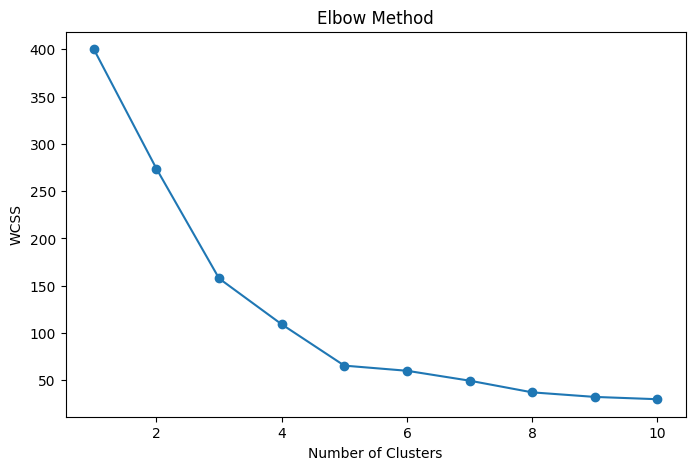

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
from sklearn.metrics import silhouette_score
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
print(f"K={i}, Silhouette Score={score}")

K=10, Silhouette Score=0.44475993501732874


In [11]:
kmeans = KMeans(n_clusters=5,random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


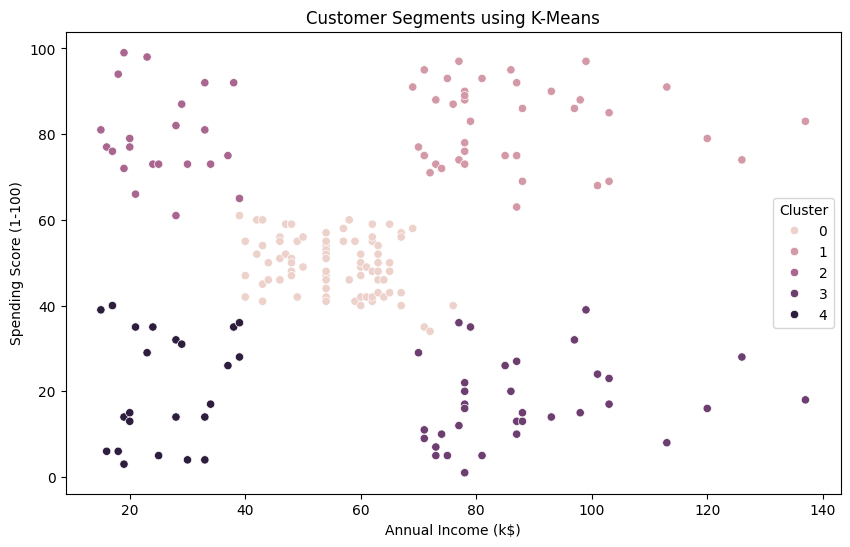

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',data=df)
plt.title("Customer Segments using K-Means")
plt.show()

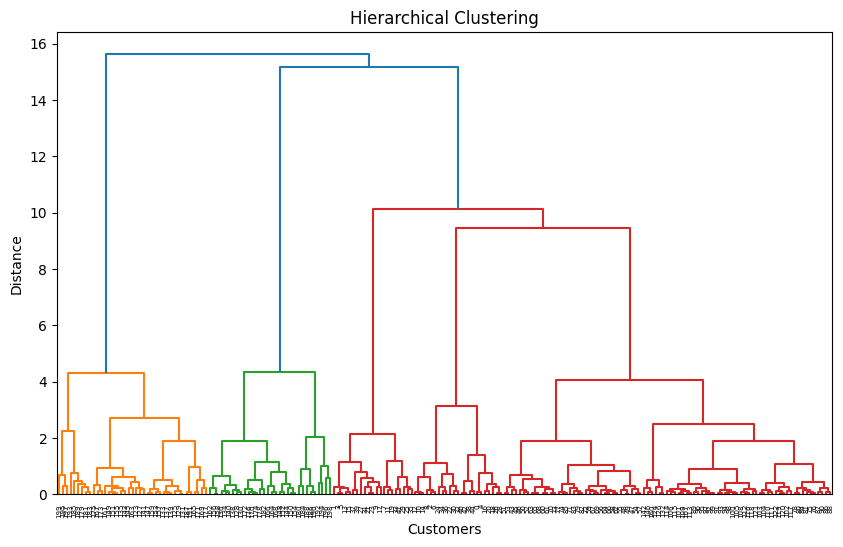

In [13]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
plt.figure(figsize=(10,6))
dendrogram(linkage(X_scaled,method='ward'))
plt.title("Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

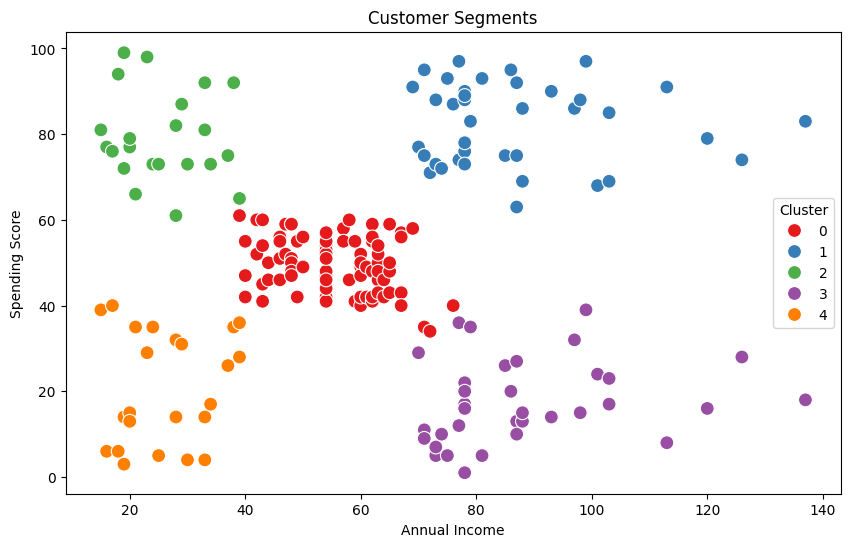

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',palette='Set1',data=df,s=100)
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title='Cluster')
plt.show()

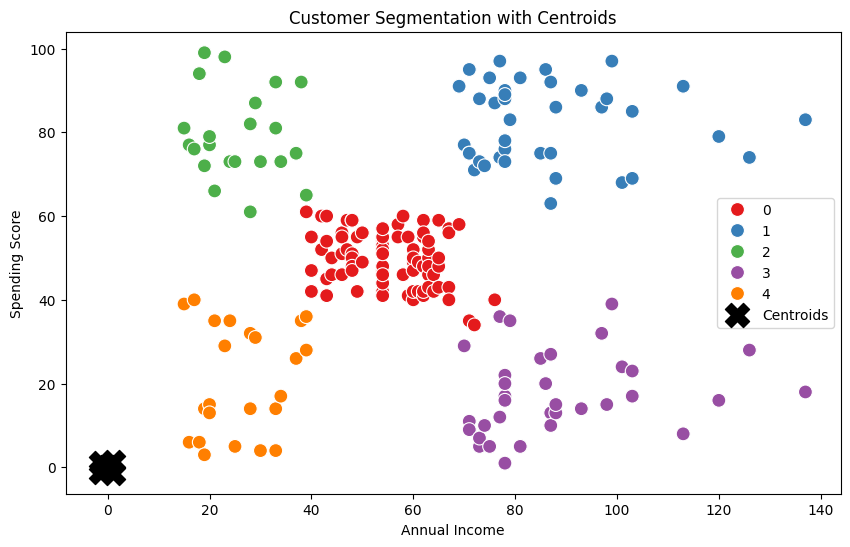

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='Cluster',palette='Set1',data=df,s=100)

plt.scatter(centroids[:,0],centroids[:,1],s=300,c='black',marker='X',label='Centroids')
plt.title("Customer Segmentation with Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [16]:
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [17]:
cluster_analysis = df.groupby('Cluster'
)[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()
print(cluster_analysis)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


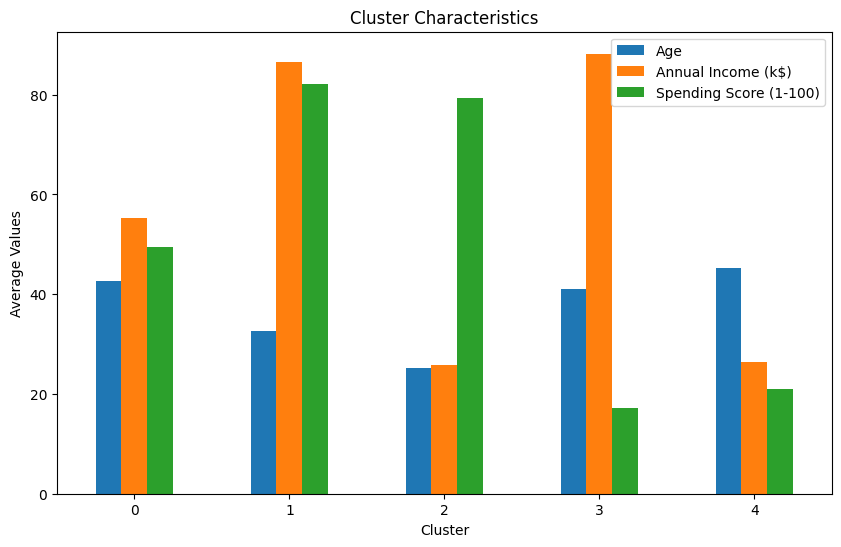

In [18]:
cluster_analysis.plot(kind='bar',figsize=(10,6))
plt.title("Cluster Characteristics")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()